<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week12/Day4/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pokemon Win Prediction Analysis
**Data Preparation**

Load and merge pokemon.csv and combats.csv.
Fix missing values:
Fill the missing Name for Pokemon #63 (Primeape).
Handle NaN values in Type 2 (mark as “None” if missing).
Calculate each Pokemon’s win percentage using the combat data.


In [ ]:
# imports

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

print ("importations done!")

importations done!


In [ ]:
# Load data
pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

In [ ]:
pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [ ]:
print ('\nShape database')  # dataset of 800 pokemons
print(pokemon.shape)


Shape database
(800, 12)


In [ ]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [ ]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [ ]:
# treament missing values

print('pre')
display(pokemon[pokemon['#'] == 63])
pokemon.loc[pokemon['#'] == 63, 'Name'] = 'Primeape'

print('post')
display(pokemon[pokemon['#'] == 63])


pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

pre


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False


post


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,Primeape,Fighting,NaN,65,105,60,60,70,95,1,False


In [ ]:
print('Missing Values')

pokemon.isnull().sum()  #without missing values now

Missing Values


,0
#,0
Name,0
Type 1,0
Type 2,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


In [ ]:
# WIN RATE CALCULATION

# #counting wins per Pokémon
wins = combats['Winner'].value_counts()

# Count total number of fights (First or Second)
total_battles = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts()

# dataframe
win_rate = pd.DataFrame({
    'Total Battles': total_battles,
    'Wins': wins
}).fillna(0)

# win %
win_rate['Win_Percentage'] = win_rate['Wins'] / win_rate['Total Battles']

In [ ]:
# Merge with pokemon dataset

pokemon = pokemon.set_index('#')
pokemon = pokemon.join(win_rate)

# Pokemon who had not played battles
pokemon['Has_Battled'] = pokemon['Total Battles'].notna()

In [ ]:
pokemon['Has_Battled'].value_counts()

,count
Has_Battled,
True,784
False,16


# Exploratory Analysis & Visualization
* Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage.
* Plot a Seaborn pairplot or PairGrid for stats vs. win percentage.
* Analyze the top 10 Pokemon by win percentage and their stats.

In [ ]:
# COPY = From here, Pokémon with no recorded battles are excluded from the modeling process.

pokemon_model = pokemon.copy()

pokemon_model = pokemon_model.dropna(subset=['Win_Percentage'])

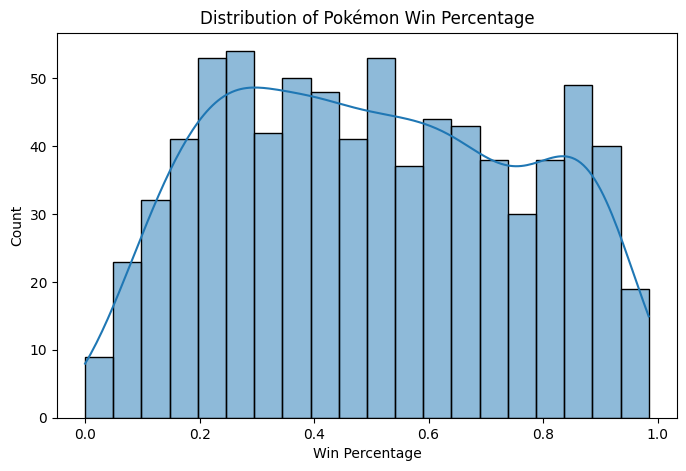

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    pokemon_model['Win_Percentage'],
    bins=20,
    kde=True
)

plt.title("Distribution of Pokémon Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Count")

plt.show()

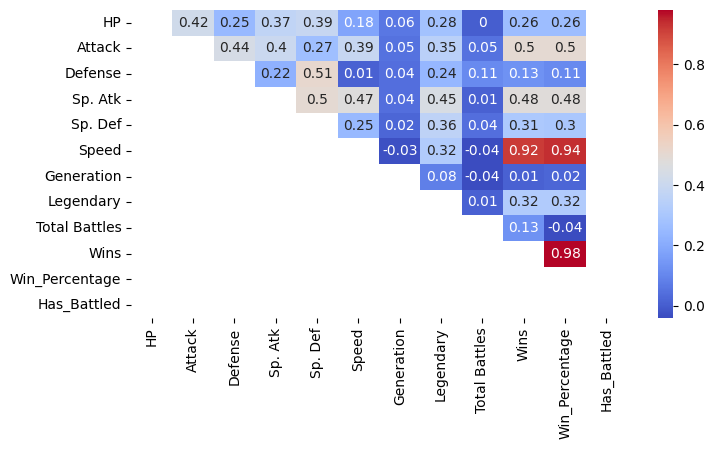

In [ ]:
corr = pokemon_model .corr(numeric_only=True).round(2)

# mask to hide bottom triangle
mask = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,4))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

# Key attributes for winning:
# Speed ​​(corr: 0.94)
# Followed by Attack (corr: 0.5) & Sp. Atk (corr: 0.48)

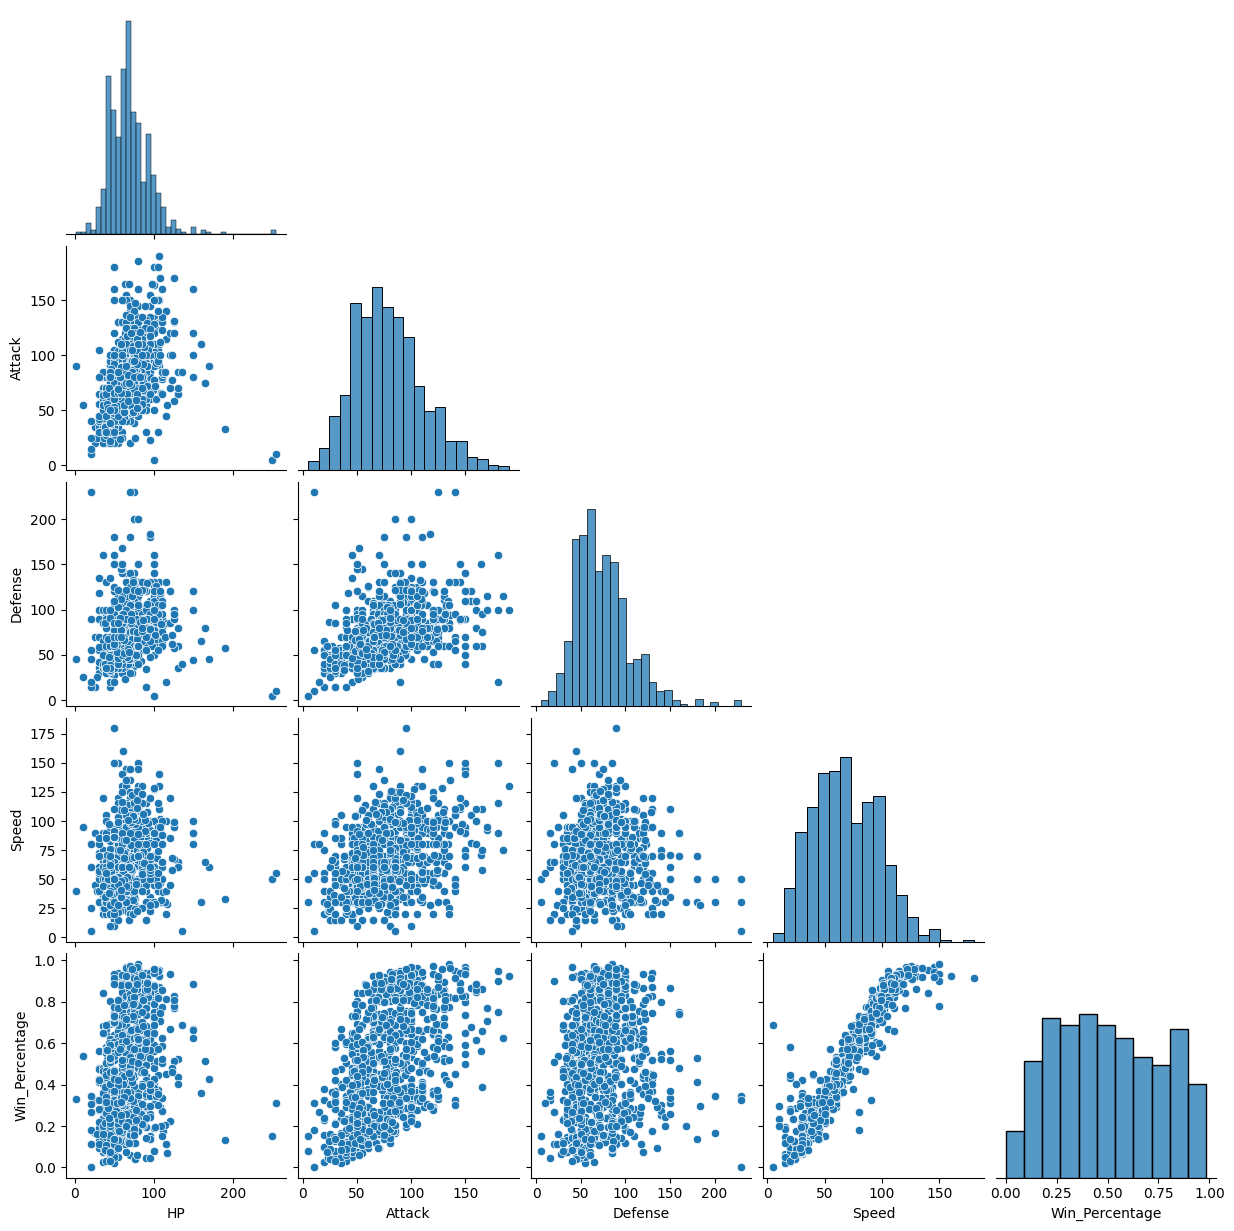

In [ ]:
sns.pairplot(
    pokemon_model[['HP', 'Attack', 'Defense', 'Speed', 'Win_Percentage']],
    corner=True
)

plt.show()

In [ ]:
# Top 10 Winner Pokemon
top10 = pokemon_model.sort_values(by='Win_Percentage', ascending=False).head(10)
display(top10)

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total Battles,Wins,Win_Percentage,Has_Battled
#,,,,,,,,,,,,,,,
155,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,1,False,129.0,127.0,0.984496,True
513,Weavile,Dark,Ice,70,120,65,45,85,125,4,False,119.0,116.0,0.974790,True
704,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,5,True,125.0,121.0,0.968000,True
20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,1,False,119.0,115.0,0.966387,True
154,Aerodactyl,Rock,Flying,80,105,65,60,75,130,1,False,141.0,136.0,0.964539,True
477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,4,False,129.0,124.0,0.961240,True
727,Greninja,Water,Dark,72,95,67,103,71,122,6,False,127.0,122.0,0.960630,True
717,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,5,False,123.0,118.0,0.959350,True
165,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,1,True,125.0,119.0,0.952000,True


# Machine Learning
* Split data into training/testing sets (80/20 split).
* Train and evaluate 3 regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage.
* Compare model performance using Mean Absolute Error (MAE).

In [ ]:
# Define variables
X = pokemon_model[['Type 1', 'Type 2', 'HP', 'Attack', 'Defense',
                   'Sp. Atk', 'Sp. Def', 'Speed', 'Legendary']]

y = pokemon_model['Win_Percentage']  # what I want to predict

In [ ]:
# Identify column types
numeric_features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
categorical_features = ['Type 1', 'Type 2']
binary_features = ['Legendary']


# Pipeline (Preprocessing scaling + onehot)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first'))
])


# Column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('bin', 'passthrough', binary_features)
])

In [ ]:
# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print()
print("Train shape:", X_train.shape)  #80%
print("Test shape:", X_test.shape)    #20%


Train shape: (627, 9)
Test shape: (157, 9)


In [ ]:
# Linear Regression

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)  #train

pred_lr = lr_model.predict(X_test)  #predict

mae_lr = mean_absolute_error(y_test, pred_lr)  #evaluate
print(f"Linear Regression MAE: {mae_lr:.4f}")

Linear Regression MAE: 0.0565


In [ ]:
# Random Forest

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)   #train

pred_rf = rf_model.predict(X_test)  #predict

mae_rf = mean_absolute_error(y_test, pred_rf)   #evaluate
print(f"Random Forest MAE: {mae_rf:.4f}")

Random Forest MAE: 0.0417


In [ ]:
# XGBoost

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    ))
])

xgb_model.fit(X_train, y_train)   #train

pred_xgb = xgb_model.predict(X_test)   #predict

mae_xgb = mean_absolute_error(y_test, pred_xgb)  #evaluate
print(f"XGBoost MAE: {mae_xgb:.4f}")


XGBoost MAE: 0.0431


In [ ]:
print("MODEL COMPARISON")
print("-" * 30)
print(f"Linear Regression MAE: {mae_lr:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")
print("-" * 30)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb]
}).sort_values(by='MAE')

best_model = results.iloc[0]

print(f"Best model: {best_model['Model']} with MAE = {best_model['MAE']:.4f}")

# Random Forest wins!

MODEL COMPARISON
------------------------------
Linear Regression MAE: 0.0565
Random Forest MAE: 0.0417
XGBoost MAE: 0.0431
------------------------------
Best model: Random Forest with MAE = 0.0417


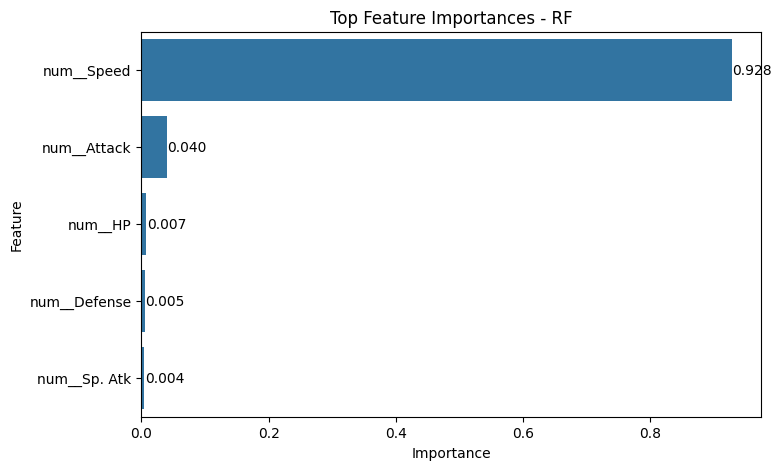

In [ ]:
# Features importance

rf_model_trained = rf_model.named_steps['model']

feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

importances = rf_model_trained.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance.head(5)


plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top Feature Importances - RF")

for i, v in enumerate(top_features['Importance']):
    ax.text(
        v + 0.001,
        i,
        f"{v:.3f}",
        va='center'
    )

plt.show()

# Most important variable: Speed ​​→ absolute key to winning battles (in line with correlation matrix)

# Conclusion
1. Random Forest achieved the best MAE. The relationships in the data, between stats and battle outcome, are nonlinear. However, they do not require complex sequential optimization. Random Forest captures the structure well.

XGBoost has a minimal difference compared to RF.

2. Speed is the dominant predictor of Pokémon win rate (correlation: 0.94, top feature importance). Attack and Sp. Atk follow as secondary factors.

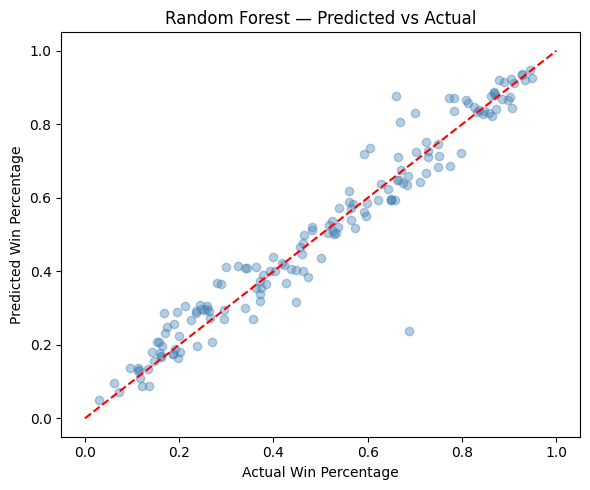

In [ ]:
# Predicted vs Actual scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_rf, alpha=0.4, color='steelblue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Actual Win Percentage')
plt.ylabel('Predicted Win Percentage')
plt.title('Random Forest — Predicted vs Actual')
plt.tight_layout()
plt.show()